In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
%matplotlib inline

In [3]:
import matplotlib
print(matplotlib.get_backend())

inline


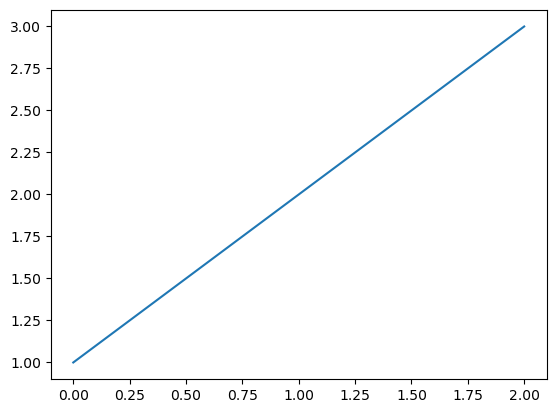

In [4]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

import matplotlib.pyplot as plt
plt.plot([1,2,3])
plt.show()

# Combinações

### Arquivos CSV e tratamento

In [5]:
df = pd.read_csv('/home/lucas/representation-fusion/resultados/combinacoes.csv')

#algumas coisas estavam erradas ao fazer a fusão: alguns estavam trocados 0 e 1 
# resultado invertido 

#1. PKLot, todos os que foram feitos com PKLot estão invertidos
mask_pklot = df['encoder'] == 'PKLot'
df.loc[mask_pklot, 'value'] = 1 - df.loc[mask_pklot, 'value']

#2. Kyoto + classificadores CNR (cameras) 
cameras = [
    'camera1', 'camera2', 'camera3', 'camera4', 'camera5',
    'camera6', 'camera7', 'camera8', 'camera9'
]

mask_kyoto_cnr = (
    (df['encoder'] == 'Kyoto') &
    (df['classificador'].isin(cameras))
)

df.loc[mask_kyoto_cnr, 'value'] = 1 - df.loc[mask_kyoto_cnr, 'value']


# 3. criar uma coluna de n_items (quantos itens tem a combinação)
df["n_items"] = df["combination"].apply(lambda x: str(x).split(",")).apply(len)
df = df[df['fusion_method'] != 'mean_probs']  # remover média pq é igual ao sum

## Contexto

No 1º artigo que foi recusado, publicamos usando sempre 10 modelos para a fusão, uma das recusas e sugestões foi testar com quantidades menores de modelos. Dessa forma, esse teste mostra os resultados com as fusões menores que 10 modelos. 

Como o André sugeriu, não precisavamos testar exatamente todas as combinações, apenas boa parte delas, então as combinações foram feitas da seguinte forma:
- Calcula o número total de combinações
- Pegava 50% delas de forma aleatória
- Exemplo: 
    - fusão de 3 modelos 
    - combinatória entre 10 (nº de modelos) x 3(para a fusão) = 120 possíveis combinações
    - 120 // 2 -> 60 combinações testadas


Sobre as fusões:
- Existem 4 tipos + comparativo:
    - Soma
    - Produto
    - Máximo
    - Votação

Sobre o protocolo de treinamento, foi separado da seguinte forma: Treino Encoder, Treino Classificador, Testes
- PKLot : [CNR1 - CNR9], [CNR1 - CNR9]
- CNR: [PUC, UFPR04, UFPR05], [PUC, UFPR04, UFPR05]
- Kyoto: [PUC, UFPR04, UFPR05, CNR1 - CNR9], [PUC, UFPR04, UFPR05, CNR1 - CNR9]

Os treinos com a base do classificador, poderia ter 5 tamanhos:
- 64
- 128
- 256
- 512 
- 1024

### Acurácia média para o tamanho da combinação

In [6]:
df.columns

Index(['encoder', 'classificador', 'teste', 'batch', 'n_models', 'combination',
       'fusion_method', 'value', 'n_items'],
      dtype='object')

Média da acurácia por tamanho da combinação, pelo batch e pelo encoder

In [7]:
df.groupby(['encoder','batch','n_items'])['value'].mean().reset_index().sort_values(['n_items', 'batch'])

,encoder,batch,n_items,value
0,CNR,64,2,0.830813
45,Kyoto,64,2,0.828377
90,PKLot,64,2,0.895647
9,CNR,128,2,0.864421
54,Kyoto,128,2,0.857206
...,...,...,...,...
80,Kyoto,512,10,0.892572
125,PKLot,512,10,0.925452
44,CNR,1024,10,0.930593
89,Kyoto,1024,10,0.905545


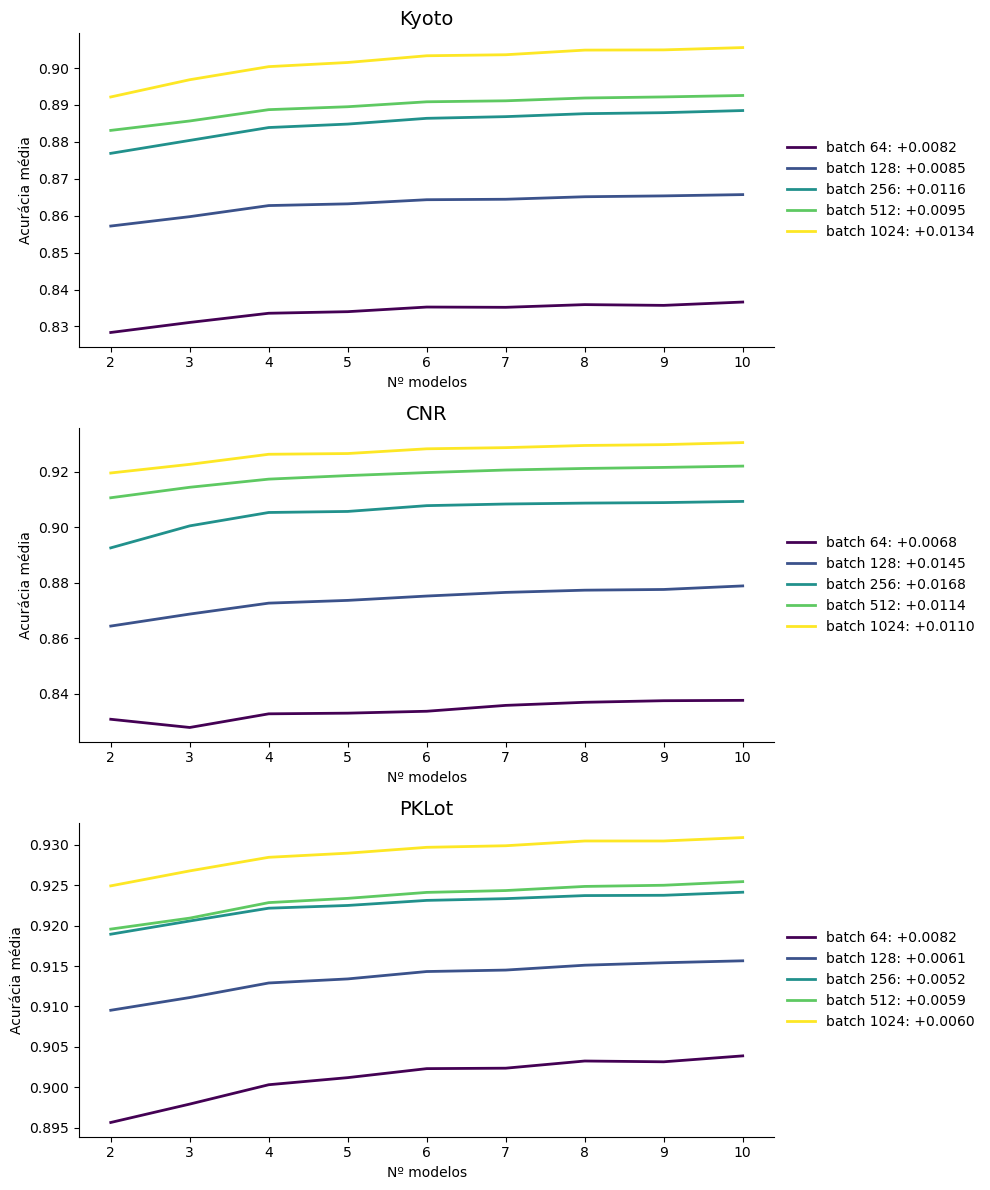

In [8]:
encoders = ['Kyoto', 'CNR', 'PKLot']
batches = [64, 128, 256, 512, 1024]

colors = plt.cm.viridis(np.linspace(0, 1, len(batches)))

fig, axes = plt.subplots(len(encoders), 1, figsize=(10, 12))

for i, encoder in enumerate(encoders):
    
    ax = axes[i]

    for j, batch in enumerate(batches):
        subset = df[
            (df['encoder'] == encoder) &
            (df['batch'] == batch)
        ]

        grouped = (
            subset
            .groupby('n_items')['value']
            .mean()
            .reset_index()
            .sort_values('n_items')
        )

        x = grouped['n_items'].values
        y = grouped['value'].values

        # ganho do primeiro para o último (ex: 2 → 10)
        gain = y[-1] - y[0]

        label = f"batch {batch}: +{gain:.4f}"

        ax.plot(
            x, y,
            label=label,
            color=colors[j],
            linewidth=2
        )

    ax.set_title(f'{encoder}', fontsize=14)
    ax.set_xlabel('Nº modelos')
    ax.set_ylabel('Acurácia média')

    # legenda fora
    ax.legend(
        loc='center left',
        bbox_to_anchor=(1, 0.5),
        frameon=False
    )

    # estilo clean
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Agora analisando caso a caso e vendo se faz diferença ou não o número de combinações aumentar

In [ ]:
results = []

group_cols = ['encoder', 'classificador', 'teste', 'batch', 'fusion_method']

for keys, group in df.groupby(group_cols):
    
    group = group.sort_values('n_items')

    val_2  = group[group['n_items'] == 2]['value'].mean()
    val_10 = group[group['n_items'] == 10]['value'].mean()

    diff = val_10 - val_2

    results.append((*keys, val_2, val_10, diff))

df_diff = pd.DataFrame(results, columns=group_cols + ['val_2', 'val_10', 'diff'])

#### maior ganho

In [ ]:
max_row = df_diff.loc[df_diff['diff'].idxmax()]
max_row

#### análise do dataframe de diff

In [ ]:
df_diff[df_diff['batch'] == 64].describe()

In [ ]:
df_diff[df_diff['batch'] == 1024].describe()

#### maiores ganhos

In [ ]:
df_diff.sort_values('diff', ascending=False).head(10)

- Os maiores ganhos acontecem sempre entre classificador x teste diferentes
- o que é um bom sinal para cross-domain
- Além disso, 9 dos 10 casos acontece na Kyoto, o que faz com que as fusões no STF (self taught learning) sejam mais impactadas por isso (grande maioria pq os valores estavam mais baixos e a fusão deixa os valores mais consistentes)

In [ ]:
#outro exemplo doq falo acima, é que em 5% de ganho, a kyoto é a que mais tem (pode ser impacto por havar mais combinações dela, mas é um indicativo)
df_diff[df_diff['diff'] > 0.05].value_counts('encoder') #mesma coisa acontece com outros valores

#### maiores ganhos acima de 95%

In [ ]:
df_diff[df_diff['val_2'] > 0.95].sort_values('diff', ascending=False).head(10)

Nesse cenário, onde estou filtrando apenas para as acurácias altas, os resultados evidenciam
- CNR é a maior predominante
- A fusão melhora apenas 1% em acurácias altas


#### menor diferença

In [ ]:
df_diff.sort_values('diff', ascending=True).head(10)

Percebemos que em alguns casos, as fusões acabam piorando a performance, diminuindo até 5% da acurácia 


#### diferença média por encoder

In [ ]:
df_diff.groupby(['encoder']).agg({'diff': ['mean', 'std', 'min', 'max']}).reset_index().sort_values(('diff', 'mean'), ascending=False)

#### diferenças pelo método de fusão

In [ ]:
df_diff.groupby(['fusion_method']).agg({'diff': ['mean', 'std', 'min', 'max']}).reset_index().sort_values(('diff', 'mean'), ascending=False)

### Análisando o impacto de um autoencoder na combinação

In [ ]:
import ast

df['combination'] = df['combination'].apply(ast.literal_eval)

for i in range(10):
    df[f'model_{i}'] = df['combination'].apply(lambda x: int(i in x))
    
df

### Impacto de cada modelo

In [ ]:
df_filter = df[df['n_items'] == 2]

corr_value = (
    df_filter[[f'model_{i}' for i in range(10)] + ['value']]
    .corr()['value']
    .drop('value')
)

sns.heatmap(
    corr_value.to_frame(),
    annot=True,
    fmt=".5f",
)

In [ ]:
corr_value = (
    df[[f'model_{i}' for i in range(10)] + ['value']]
    .corr()['value']
    .drop('value')
)

sns.heatmap(
    corr_value.to_frame(),
    annot=True,
    fmt=".5f",
)

De forma geral, os modelos que mais impactam são o Modelo1 e Modelo6

### Impacto de cada modelo por Batch

In [ ]:
batches = sorted(df['batch'].unique())

fig, axes = plt.subplots(1, len(batches), figsize=(20, 4))

for idx, batch in enumerate(batches):
    ax = axes[idx]

    df_filter = df[df['batch'] == batch]

    corr_value = (
        df_filter[[f'model_{i}' for i in range(10)] + ['value']]
        .corr()['value']
        .drop('value')
    )

    sns.heatmap(
        corr_value.to_frame(),
        annot=True,
        fmt=".5f",
        ax=ax,
        cbar=(idx == len(batches) - 1)  # só um colorbar
    )

    ax.set_title(f'Batch {batch}')

plt.tight_layout()
plt.show()

### Explicações para o impacto de cada modelo:

In [ ]:
df_models = pd.read_csv('/home/lucas/representation-fusion/resultados_pibic_ano_passado/precisao.csv')
df_models.head(2)

In [ ]:
df_models.groupby(['modelo', 'encoder']).agg({'value': ['mean', 'std', 'min', 'max']})

In [ ]:
df[df['fusion_method'] == 'mult'].groupby(['encoder']).agg({'value': ['mean', 'std', 'min', 'max']})

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
import zipfile
import tempfile
import os
import json

def load_model(model_num):
    """
    Carrega um modelo salvo no formato .keras dado o número do modelo (0-9).
    Retorna o classificador completo e o encoder separadamente.
    Recria o modelo manualmente baseado na config extraída do .keras para lidar com estruturas diferentes.
    """
    path = f"/home/lucas/representation-fusion/Modelos/Modelo_Kyoto-{model_num}/Classificador-PKLot/Estrutura/Classificador_Modelo_Kyoto-{model_num}.keras"

    # Extrair config.json e weights
    with tempfile.TemporaryDirectory() as temp_dir:
        with zipfile.ZipFile(path, 'r') as zf:
            zf.extract('config.json', temp_dir)
            zf.extract('model.weights.h5', temp_dir)
        temp_config = os.path.join(temp_dir, 'config.json')
        temp_weights = os.path.join(temp_dir, 'model.weights.h5')

        with open(temp_config, 'r') as f:
            config = json.load(f)

        # Parse layers
        main_layers = config['config']['layers']
        encoder_layers = main_layers[1]['config']['layers']  # the Functional layers

        # Create encoder
        encoder_input = layers.Input(shape=(64, 64, 3))
        x = encoder_input
        for layer in encoder_layers[1:]:  # skip input
            if layer['class_name'] == 'Conv2D':
                filters = layer['config']['filters']
                x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
            elif layer['class_name'] == 'MaxPooling2D':
                x = layers.MaxPooling2D((2, 2), padding='same')(x)
            elif layer['class_name'] == 'Flatten':
                x = layers.Flatten()(x)
            elif layer['class_name'] == 'Dense':
                units = layer['config']['units']
                activation = layer['config']['activation']
                trainable = layer['config']['trainable']
                x = layers.Dense(units, activation=activation)(x)
        encoder = keras.Model(encoder_input, x, name=f'encoder_{model_num}')
        encoder.trainable = False

        # Create main model (classificador)
        model_input = layers.Input(shape=(64, 64, 3))
        x = encoder(model_input)
        for layer in main_layers[2:]:  # skip input and functional
            if layer['class_name'] == 'Dropout':
                rate = layer['config']['rate']
                x = layers.Dropout(rate)(x)
            elif layer['class_name'] == 'Dense':
                units = layer['config']['units']
                activation = layer['config']['activation']
                x = layers.Dense(units, activation=activation)(x)
        model = keras.Model(model_input, x, name=f'classificadorModelo_Kyoto-{model_num}')

        # Carregar pesos
        model.load_weights(temp_weights)

    return model, encoder

def analisar_modelo(modelo, encoder):
    """
    Analisa o modelo e encoder, retornando informações solicitadas.
    """
    info = {}

    info['modelo'] = modelo.name

    # Total de parâmetros
    info['total_parametros'] = modelo.count_params()

    # Parâmetros do encoder
    info['parametros_encoder'] = encoder.count_params()

    # Camadas de convolução
    info['numero_camadas_convolucao'] = len([layer.name for layer in encoder.layers if isinstance(layer, layers.Conv2D)])

    # Camadas de pool
    info['numero_camadas_pool'] = len([layer.name for layer in encoder.layers if isinstance(layer, layers.MaxPooling2D)])

    # Output shape do encoder
    info['output_shape_encoder'] = np.array(encoder.output.shape)[1:][0]  # remove batch dimension

    # Número de camadas do encoder
    info['numero_camadas_encoder'] = len(encoder.layers)

    return info

values = []
for i, corr in enumerate(corr_value):
    classificador, encoder = load_model(i)
    info = analisar_modelo(classificador, encoder)
    #info['correlacao'] = corr
    values.append(info)

df_info_models = pd.DataFrame(values)
df_info_models['model_num'] = df_info_models['modelo'].apply(lambda x: int(x.split('-')[1]))
df_info_models


In [ ]:
df_models['model_num'] = df_models['modelo'].apply(lambda x: int(str(x)[-1]))

In [ ]:
df_models.columns

In [ ]:
df_models = df_models.merge(df_info_models, on='model_num', how='left', suffixes=('', '_info'))
df_analise = df_models[['model_num', 'encoder', 'classificador', 'teste', 'batch', 'value', 'total_parametros', 'parametros_encoder', 'numero_camadas_convolucao', 'numero_camadas_pool', 'output_shape_encoder', 'numero_camadas_encoder']]
df_analise

In [ ]:
df_num = df_analise.select_dtypes(include=['number'])
corr = df_num.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.tight_layout()

plt.show()